# Análisis de Línea RGB en Imagen
Este notebook realiza un barrido de una línea de imagen y separa los canales R, G, B mostrando la intensidad vs píxeles

In [163]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

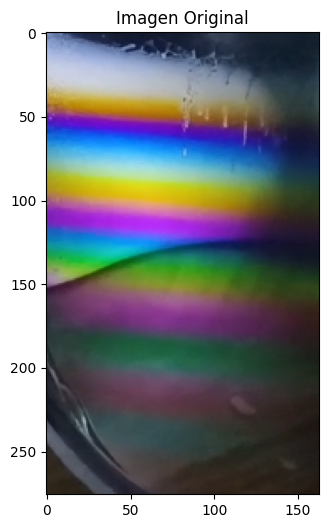

Dimensiones de la imagen: (276, 163, 3)


In [164]:
# Cargar la imagen
# Opción 1: Usar una imagen de ejemplo
imagen_path = 'patron.PNG'

# Opción 2: Crear una imagen de prueba con gradientes de colores
# Crear imagen de prueba
ancho, alto = 800, 600
imagen_test = np.zeros((alto, ancho, 3), dtype=np.uint8)

# Gradiente rojo
imagen_test[:, :267, 0] = np.linspace(0, 255, 267).astype(np.uint8)
# Gradiente verde
imagen_test[:, 267:534, 1] = np.linspace(0, 255, 267).astype(np.uint8)
# Gradiente azul
imagen_test[:, 534:, 2] = np.linspace(0, 255, 266).astype(np.uint8)

# Si tienes tu propia imagen, descomenta esto:
imagen = cv2.imread(imagen_path)
imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

#imagen = imagen_test

# Mostrar la imagen
plt.figure(figsize=(12, 6))
plt.imshow(imagen)
plt.title('Imagen Original')
plt.axis('on')
plt.show()

print(f"Dimensiones de la imagen: {imagen.shape}")

In [165]:
# Seleccionar una columna desplazada a la derecha del centro
desplazamiento = -50  # Ajusta este valor según cuánto quieras desplazar
fila = (imagen.shape[1] // 2) + desplazamiento  # Columna desplazada a la derecha

# Verificar que no se salga de los límites de la imagen
if fila >= imagen.shape[1]:
    fila = imagen.shape[1] - 1
    print(f"Desplazamiento ajustado al límite de la imagen")

print(f"Analizando la columna {fila} de la imagen")

# Extraer la línea VERTICAL
linea = imagen[:, fila, :]

# Separar los canales R, G, B
canal_rojo = linea[:, 0]
canal_verde = linea[:, 1]
canal_azul = linea[:, 2]

# Crear array de posiciones de píxeles
pixeles = np.arange(len(canal_rojo))

print(f"Número de píxeles en la línea: {len(pixeles)}")

Analizando la columna 31 de la imagen
Número de píxeles en la línea: 276


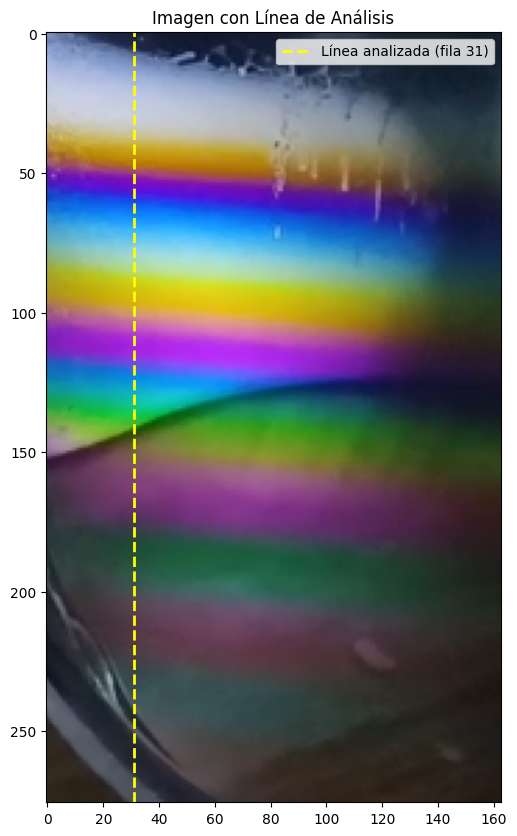

In [166]:
# Mostrar la imagen con la línea seleccionada marcada
plt.figure(figsize=(8, 10))
plt.imshow(imagen)
plt.axvline(x=fila, color='yellow', linestyle='--', linewidth=2, label=f'Línea analizada (fila {fila})')
plt.title('Imagen con Línea de Análisis')
plt.legend()
plt.axis('on')
plt.show()

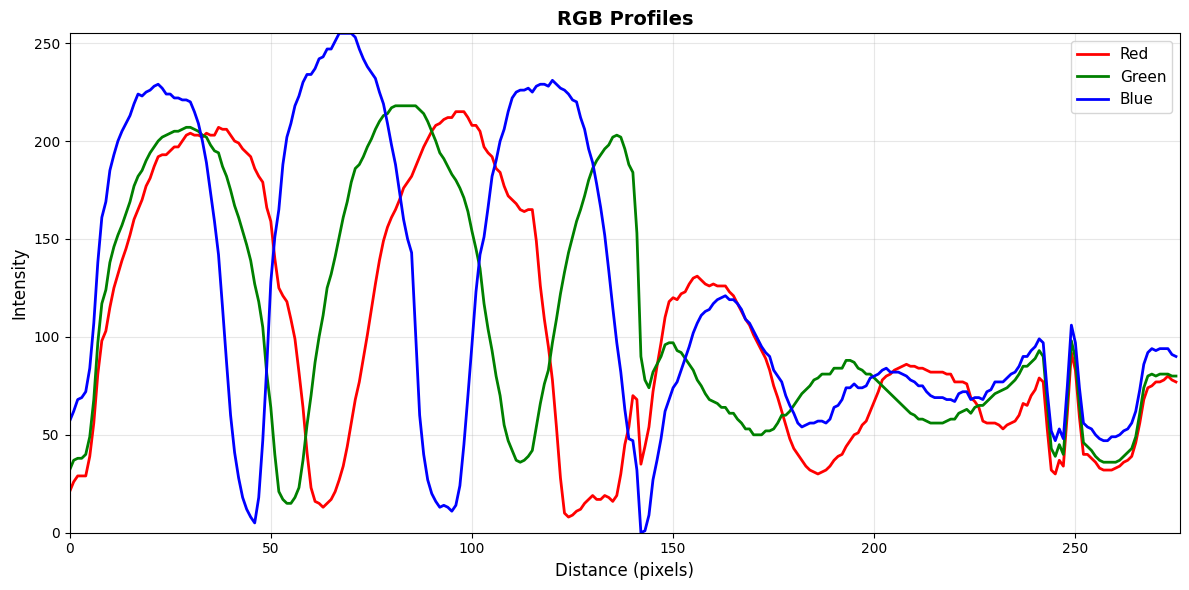

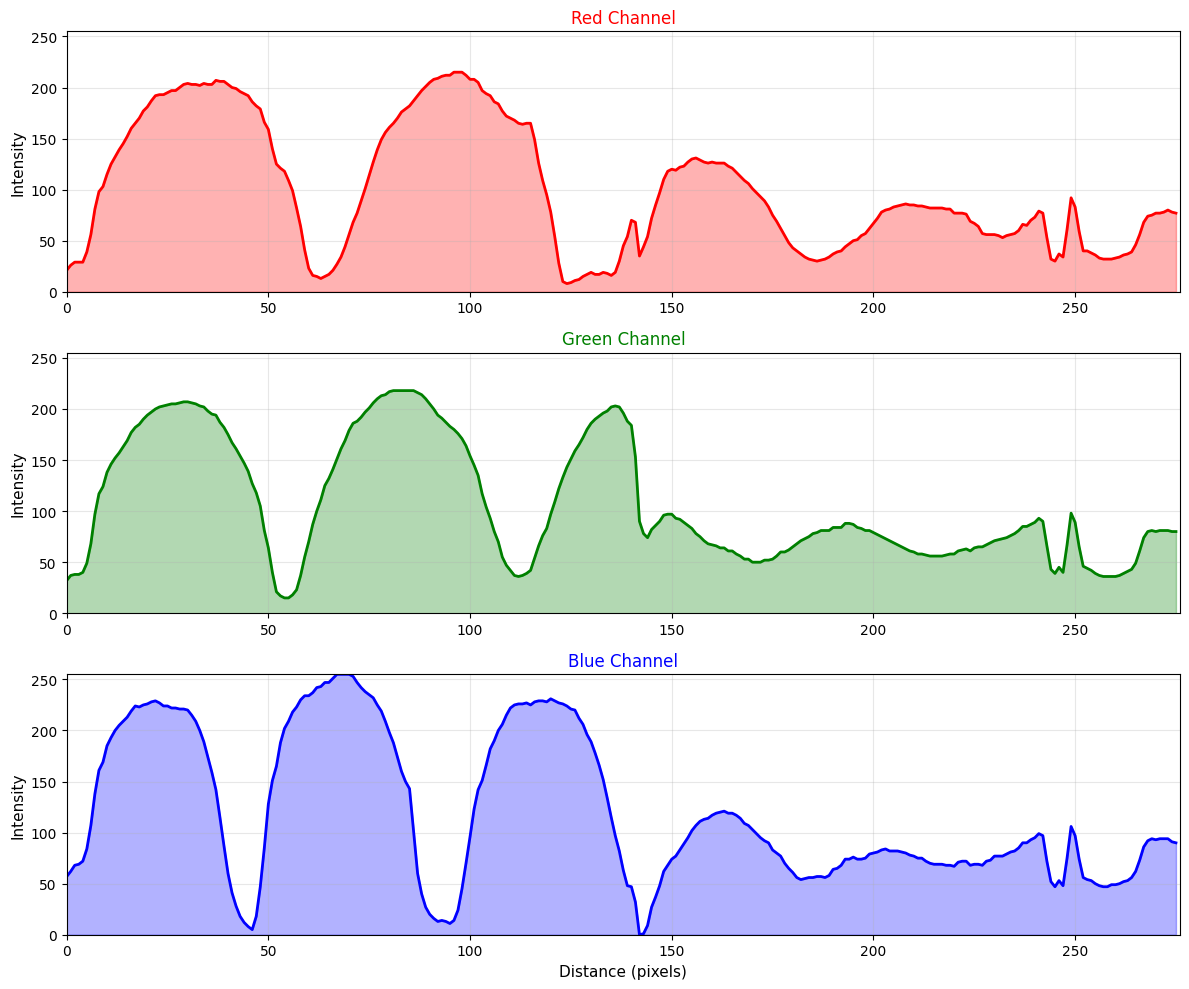

In [167]:
# Graficar los tres canales juntos (como en ImageJ)
plt.figure(figsize=(12, 6))
plt.plot(pixeles, canal_rojo, 'r-', label='Red', linewidth=2)
plt.plot(pixeles, canal_verde, 'g-', label='Green', linewidth=2)
plt.plot(pixeles, canal_azul, 'b-', label='Blue', linewidth=2)
plt.xlabel('Distance (pixels)', fontsize=12)
plt.ylabel('Intensity', fontsize=12)
plt.title('RGB Profiles', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim(0, 255)
plt.xlim(0, len(pixeles))
plt.tight_layout()
plt.show()

# Gráficas individuales de cada canal
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Canal Rojo
axes[0].plot(pixeles, canal_rojo, 'r-', linewidth=2)
axes[0].fill_between(pixeles, canal_rojo, alpha=0.3, color='red')
axes[0].set_ylabel('Intensity', fontsize=11)
axes[0].set_title('Red Channel', fontsize=12, color='red')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 255)
axes[0].set_xlim(0, len(pixeles))

# Canal Verde
axes[1].plot(pixeles, canal_verde, 'g-', linewidth=2)
axes[1].fill_between(pixeles, canal_verde, alpha=0.3, color='green')
axes[1].set_ylabel('Intensity', fontsize=11)
axes[1].set_title('Green Channel', fontsize=12, color='green')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 255)
axes[1].set_xlim(0, len(pixeles))

# Canal Azul
axes[2].plot(pixeles, canal_azul, 'b-', linewidth=2)
axes[2].fill_between(pixeles, canal_azul, alpha=0.3, color='blue')
axes[2].set_xlabel('Distance (pixels)', fontsize=11)
axes[2].set_ylabel('Intensity', fontsize=11)
axes[2].set_title('Blue Channel', fontsize=12, color='blue')
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0, 255)
axes[2].set_xlim(0, len(pixeles))

plt.tight_layout()
plt.show()

In [168]:
# Estadísticas de cada canal
print("=" * 60)
print("ESTADÍSTICAS DE LOS CANALES")
print("=" * 60)

print("\nCanal Rojo:")
print(f"  Media: {np.mean(canal_rojo):.2f}")
print(f"  Mediana: {np.median(canal_rojo):.2f}")
print(f"  Desviación estándar: {np.std(canal_rojo):.2f}")
print(f"  Mínimo: {np.min(canal_rojo)}")
print(f"  Máximo: {np.max(canal_rojo)}")

print("\nCanal Verde:")
print(f"  Media: {np.mean(canal_verde):.2f}")
print(f"  Mediana: {np.median(canal_verde):.2f}")
print(f"  Desviación estándar: {np.std(canal_verde):.2f}")
print(f"  Mínimo: {np.min(canal_verde)}")
print(f"  Máximo: {np.max(canal_verde)}")

print("\nCanal Azul:")
print(f"  Media: {np.mean(canal_azul):.2f}")
print(f"  Mediana: {np.median(canal_azul):.2f}")
print(f"  Desviación estándar: {np.std(canal_azul):.2f}")
print(f"  Mínimo: {np.min(canal_azul)}")
print(f"  Máximo: {np.max(canal_azul)}")

ESTADÍSTICAS DE LOS CANALES

Canal Rojo:
  Media: 100.36
  Mediana: 82.00
  Desviación estándar: 62.47
  Mínimo: 8
  Máximo: 215

Canal Verde:
  Media: 107.19
  Mediana: 81.50
  Desviación estándar: 59.93
  Mínimo: 15
  Máximo: 218

Canal Azul:
  Media: 120.15
  Mediana: 92.00
  Desviación estándar: 72.50
  Mínimo: 0
  Máximo: 255


In [169]:
# Exportar datos a un archivo CSV (opcional)
import pandas as pd

df = pd.DataFrame({
    'Pixel': pixeles,
    'Rojo': canal_rojo,
    'Verde': canal_verde,
    'Azul': canal_azul
})

# Guardar a CSV
df.to_csv('datos_linea_rgb.csv', index=False)
print("Datos exportados a 'datos_linea_rgb.csv'")

# Mostrar primeras filas
print("\nPrimeras 10 filas de datos:")
print(df.head(10))

Datos exportados a 'datos_linea_rgb.csv'

Primeras 10 filas de datos:
   Pixel  Rojo  Verde  Azul
0      0    21     32    57
1      1    26     37    62
2      2    29     38    68
3      3    29     38    69
4      4    29     40    72
5      5    39     49    84
6      6    56     68   107
7      7    81     97   138
8      8    98    117   161
9      9   103    124   169


In [170]:
# 1. LOCALIZAR LOS MÍNIMOS EN CADA COLOR
from scipy.signal import find_peaks

# Invertir señales para encontrar mínimos como máximos
canal_rojo_inv = -canal_rojo
canal_verde_inv = -canal_verde
canal_azul_inv = -canal_azul

# Encontrar los picos (que son mínimos en la señal original)
# distance: distancia mínima entre picos (ajustar según necesidad)
# prominence: prominencia mínima del pico
minimos_rojo, _ = find_peaks(canal_rojo_inv, distance=20, prominence=10)
minimos_verde, _ = find_peaks(canal_verde_inv, distance=20, prominence=10)
minimos_azul, _ = find_peaks(canal_azul_inv, distance=20, prominence=10)

# Forzar el píxel 0 como primer mínimo común (m=0) para los tres canales
# Esto hace que todos comiencen en el mismo punto de referencia
minimos_rojo = np.insert(minimos_rojo, 0, 0)
minimos_verde = np.insert(minimos_verde, 0, 0)
minimos_azul = np.insert(minimos_azul, 0, 0)

print("=" * 60)
print("MÍNIMOS DETECTADOS EN CADA CANAL")
print("=" * 60)

print(f"\nCanal Rojo: {len(minimos_rojo)} mínimos detectados")
print(f"Posiciones (píxeles): {minimos_rojo}")
print(f"Valores de intensidad: {canal_rojo[minimos_rojo]}")

print(f"\nCanal Verde: {len(minimos_verde)} mínimos detectados")
print(f"Posiciones (píxeles): {minimos_verde}")
print(f"Valores de intensidad: {canal_verde[minimos_verde]}")

print(f"\nCanal Azul: {len(minimos_azul)} mínimos detectados")
print(f"Posiciones (píxeles): {minimos_azul}")
print(f"Valores de intensidad: {canal_azul[minimos_azul]}")

MÍNIMOS DETECTADOS EN CADA CANAL

Canal Rojo: 5 mínimos detectados
Posiciones (píxeles): [  0  63 124 186 245]
Valores de intensidad: [21 13  8 30 30]

Canal Verde: 7 mínimos detectados
Posiciones (píxeles): [  0  54 112 144 171 215 258]
Valores de intensidad: [32 15 36 74 50 56 36]

Canal Azul: 7 mínimos detectados
Posiciones (píxeles): [  0  46  95 143 182 220 245]
Valores de intensidad: [57  5 11  1 54 67 47]


In [171]:
# 2. CREAR DATAFRAMES CON DISTANCIAS Y ESPESORES
# Fórmula: espesor = m * lambda / 2
# donde m es el orden de interferencia (1, 2, 3, ...)
# lambda es la longitud de onda del color

# Longitudes de onda características (en nm)
lambda_rojo = 650   # nm
lambda_verde = 530  # nm
lambda_azul = 470   # nm

# Crear DataFrames para cada color
# X = distancias en píxeles
# Y = espesores calculados

# DataFrame para canal Rojo
# Calcular distancias relativas al primer mínimo (X=0 en el primer mínimo)
distancias_rojo = minimos_rojo - minimos_rojo[0] if len(minimos_rojo) > 0 else []
df_rojo = pd.DataFrame({
    'X_pixel': distancias_rojo,
    'orden_m': range(1, len(minimos_rojo) + 1),
    'Y_espesor_nm': [(m * lambda_rojo / 2) for m in range(0, len(minimos_rojo))]
})

# DataFrame para canal Verde
distancias_verde = minimos_verde - minimos_verde[0] if len(minimos_verde) > 0 else []
df_verde = pd.DataFrame({
    'X_pixel': distancias_verde,
    'orden_m': range(1, len(minimos_verde) + 1),
    'Y_espesor_nm': [(m * lambda_verde / 2) for m in range(0, len(minimos_verde) )]
})

# DataFrame para canal Azul
distancias_azul = minimos_azul - minimos_azul[0] if len(minimos_azul) > 0 else []
df_azul = pd.DataFrame({
    'X_pixel': distancias_azul,
    'orden_m': range(1, len(minimos_azul) + 1),
    'Y_espesor_nm': [(m * lambda_azul / 2) for m in range(0, len(minimos_azul) )]
})

print("=" * 60)
print("DATAFRAMES CON DISTANCIAS Y ESPESORES")
print("=" * 60)

print("\nCanal Rojo:")
print(df_rojo)

print("\nCanal Verde:")
print(df_verde)

print("\nCanal Azul:")
print(df_azul)

DATAFRAMES CON DISTANCIAS Y ESPESORES

Canal Rojo:
   X_pixel  orden_m  Y_espesor_nm
0        0        1           0.0
1       63        2         325.0
2      124        3         650.0
3      186        4         975.0
4      245        5        1300.0

Canal Verde:
   X_pixel  orden_m  Y_espesor_nm
0        0        1           0.0
1       54        2         265.0
2      112        3         530.0
3      144        4         795.0
4      171        5        1060.0
5      215        6        1325.0
6      258        7        1590.0

Canal Azul:
   X_pixel  orden_m  Y_espesor_nm
0        0        1           0.0
1       46        2         235.0
2       95        3         470.0
3      143        4         705.0
4      182        5         940.0
5      220        6        1175.0
6      245        7        1410.0


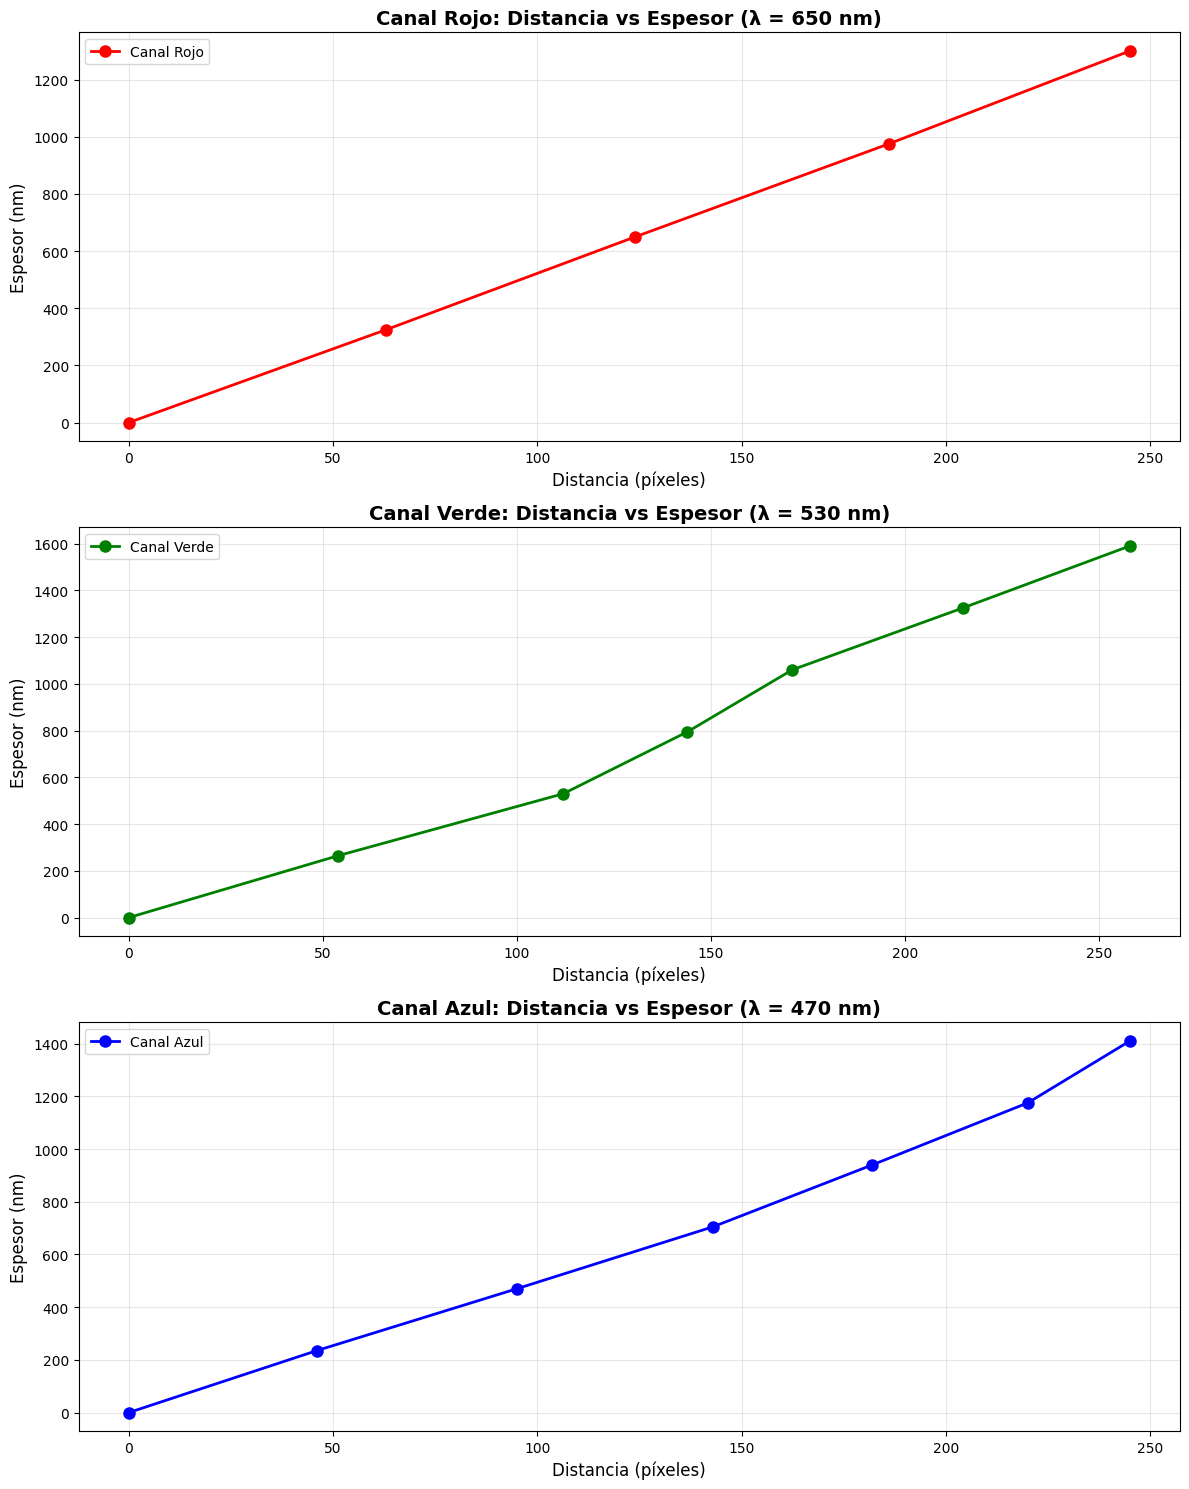

In [172]:
# 3. GRAFICAR X CONTRA Y

fig, axes = plt.subplots(3, 1, figsize=(12, 15))

# Gráfico para canal Rojo
if len(df_rojo) > 0:
    axes[0].plot(df_rojo['X_pixel'], df_rojo['Y_espesor_nm'], 
                 'ro-', linewidth=2, markersize=8, label='Canal Rojo')
    axes[0].set_xlabel('Distancia (píxeles)', fontsize=12)
    axes[0].set_ylabel('Espesor (nm)', fontsize=12)
    axes[0].set_title(f'Canal Rojo: Distancia vs Espesor (λ = {lambda_rojo} nm)', 
                      fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, 'No se detectaron mínimos', 
                ha='center', va='center', transform=axes[0].transAxes)

# Gráfico para canal Verde
if len(df_verde) > 0:
    axes[1].plot(df_verde['X_pixel'], df_verde['Y_espesor_nm'], 
                 'go-', linewidth=2, markersize=8, label='Canal Verde')
    axes[1].set_xlabel('Distancia (píxeles)', fontsize=12)
    axes[1].set_ylabel('Espesor (nm)', fontsize=12)
    axes[1].set_title(f'Canal Verde: Distancia vs Espesor (λ = {lambda_verde} nm)', 
                      fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'No se detectaron mínimos', 
                ha='center', va='center', transform=axes[1].transAxes)

# Gráfico para canal Azul
if len(df_azul) > 0:
    axes[2].plot(df_azul['X_pixel'], df_azul['Y_espesor_nm'], 
                 'bo-', linewidth=2, markersize=8, label='Canal Azul')
    axes[2].set_xlabel('Distancia (píxeles)', fontsize=12)
    axes[2].set_ylabel('Espesor (nm)', fontsize=12)
    axes[2].set_title(f'Canal Azul: Distancia vs Espesor (λ = {lambda_azul} nm)', 
                      fontsize=14, fontweight='bold')
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()
else:
    axes[2].text(0.5, 0.5, 'No se detectaron mínimos', 
                ha='center', va='center', transform=axes[2].transAxes)

plt.tight_layout()
plt.show()

In [173]:
# GUARDAR DATAFRAMES EN ARCHIVOS CSV

df_rojo.to_csv('minimos_rojo_espesores.csv', index=False)
df_verde.to_csv('minimos_verde_espesores.csv', index=False)
df_azul.to_csv('minimos_azul_espesores.csv', index=False)

print("=" * 60)
print("ARCHIVOS CSV GUARDADOS")
print("=" * 60)
print("\n- minimos_rojo_espesores.csv")
print("- minimos_verde_espesores.csv")
print("- minimos_azul_espesores.csv")

ARCHIVOS CSV GUARDADOS

- minimos_rojo_espesores.csv
- minimos_verde_espesores.csv
- minimos_azul_espesores.csv


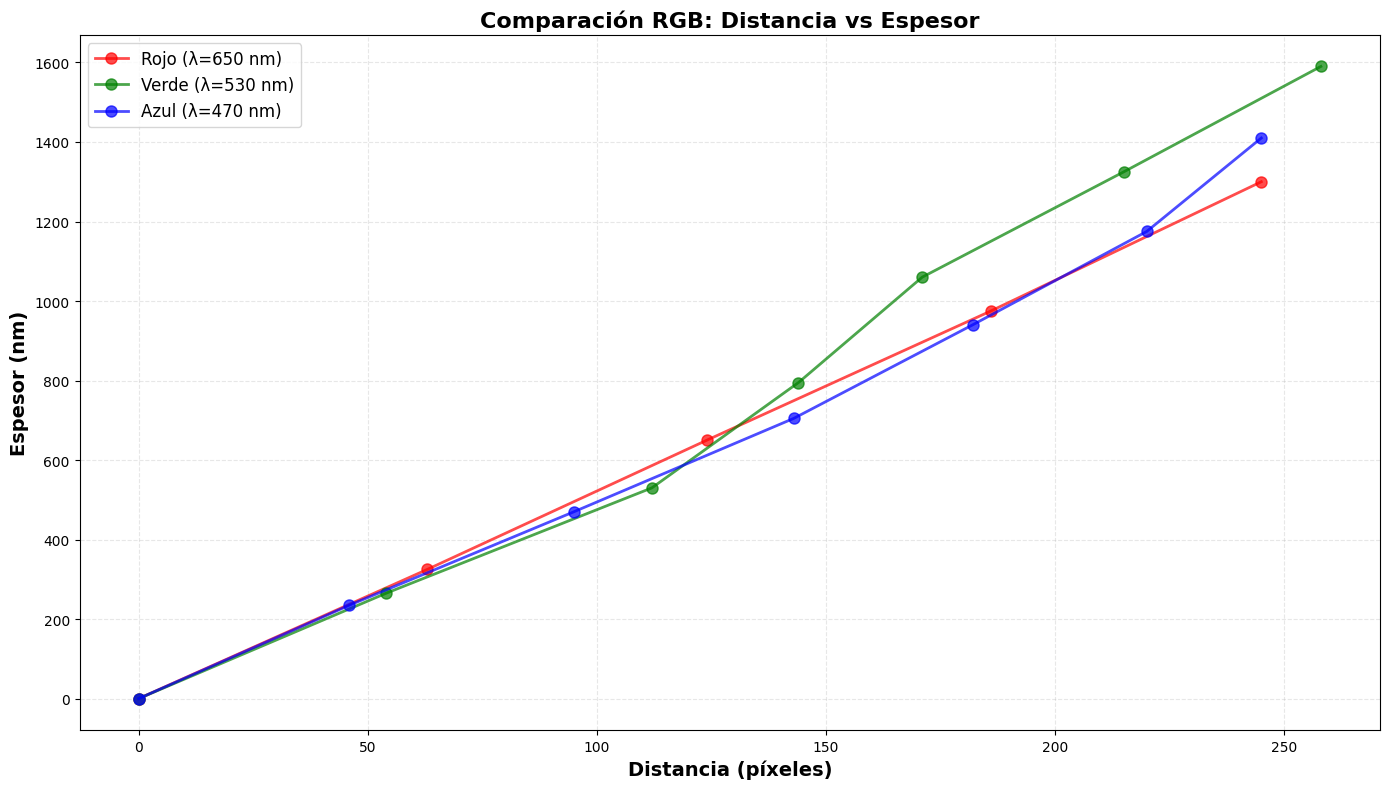

In [174]:
# GRÁFICO COMBINADO: LOS 3 COLORES JUNTOS

plt.figure(figsize=(14, 8))

# Graficar canal Rojo
if len(df_rojo) > 0:
    plt.plot(df_rojo['X_pixel'], df_rojo['Y_espesor_nm'], 
             'ro-', linewidth=2, markersize=8, label=f'Rojo (λ={lambda_rojo} nm)', alpha=0.7)

# Graficar canal Verde
if len(df_verde) > 0:
    plt.plot(df_verde['X_pixel'], df_verde['Y_espesor_nm'], 
             'go-', linewidth=2, markersize=8, label=f'Verde (λ={lambda_verde} nm)', alpha=0.7)

# Graficar canal Azul
if len(df_azul) > 0:
    plt.plot(df_azul['X_pixel'], df_azul['Y_espesor_nm'], 
             'bo-', linewidth=2, markersize=8, label=f'Azul (λ={lambda_azul} nm)', alpha=0.7)

plt.xlabel('Distancia (píxeles)', fontsize=14, fontweight='bold')
plt.ylabel('Espesor (nm)', fontsize=14, fontweight='bold')
plt.title('Comparación RGB: Distancia vs Espesor', fontsize=16, fontweight='bold')
plt.legend(fontsize=12, loc='best')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [175]:
print("Rojo:")
print(df_rojo)
print("\nVerde:")
print(df_verde)
print("\nAzul:")
print(df_azul)


Rojo:
   X_pixel  orden_m  Y_espesor_nm
0        0        1           0.0
1       63        2         325.0
2      124        3         650.0
3      186        4         975.0
4      245        5        1300.0

Verde:
   X_pixel  orden_m  Y_espesor_nm
0        0        1           0.0
1       54        2         265.0
2      112        3         530.0
3      144        4         795.0
4      171        5        1060.0
5      215        6        1325.0
6      258        7        1590.0

Azul:
   X_pixel  orden_m  Y_espesor_nm
0        0        1           0.0
1       46        2         235.0
2       95        3         470.0
3      143        4         705.0
4      182        5         940.0
5      220        6        1175.0
6      245        7        1410.0
